In [5]:
import sys
sys.path.append('../GC_stream')

from tqdm import tqdm
import numpy as np
import matplotlib as mpl
from matplotlib import colormaps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from scipy.stats import binned_statistic_2d, gaussian_kde
from scipy.signal import find_peaks
from scipy import linalg
from astropy.io import fits
import astropy.units as u
import astropy.coordinates as coord
import pandas as pd
from ezpadova import parsec

import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms
_ = coord.galactocentric_frame_defaults.set('v4.0')

import agama
agama.setUnits(length=1, velocity=1, mass=1)

import stream_dataset as sd
import GC
import agama_stream as ags

In [6]:
# force reimport

import importlib
importlib.reload(sd)
importlib.reload(GC)
importlib.reload(ags)

<module 'agama_stream' from '/Users/ybchen/Documents/GC_stream/notebooks/../GC_stream/agama_stream.py'>

In [7]:
def get_peri_apo(x,y,z):
    r2 = x**2 + y**2 + z**2
    median = np.median(r2)
    peaks_apo, _ = find_peaks(r2, height=median)
    peaks_peri, _ = find_peaks(-r2, height=-median)

    return peaks_apo, peaks_peri

**download and select isochrones**

In [8]:
# download isochrone

feh_list = np.array([-1.9, -1.5, -1.3, -1.1, -0.7])
Z_list = 10.0**feh_list*0.0152

# download gaia isochrone
# iso_list = [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='gaia') for Z in Z_list]
# for i in range(len(feh_list)):
#     iso_list[i].to_pandas().to_csv('../data/iso_gaia/feh%g.csv'%feh_list[i])

# download cfht isochrone
# iso_list = [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='megacam_wircam') for Z in Z_list]
# for i in range(len(feh_list)):
#     iso_list[i].to_pandas().to_csv('../data/iso_cfht/feh%g.csv'%feh_list[i])

In [9]:
# load isochrone

iso_gaia_list = []
for i in range(len(feh_list)):
    iso_gaia_list.append(pd.read_csv('../data/iso_gaia/feh%g.csv'%feh_list[i]))
    
iso_cfht_list = []
for i in range(len(feh_list)):
    iso_cfht_list.append(pd.read_csv('../data/iso_cfht/feh%g.csv'%feh_list[i]))

In [10]:
# select isochrone

def select_iso(color, mag, iso_list, color1_key, color2_key, mag_key):
    
    comp = np.inf
    idx = np.nan
    
    for j in range(len(iso_list)):
        iso = iso_list[j]
        iso_color1 = iso[color1_key]
        iso_color2 = iso[color2_key]
        iso_mag = iso[mag_key]
        
        mask = iso['label'] <= 3
        iso_color = iso_color1[mask][::-1]-iso_color2[mask][::-1]
        iso_mag = iso_mag[mask][::-1]

        dcolor = color - np.interp(mag, iso_mag, iso_color)
        dcolor = np.mean(dcolor**2)
        if dcolor < comp:
            comp = dcolor
            idx = j

    return idx

def calc_mass(mag, iso, mag_key):
    iso_mag = iso[mag_key]
    iso_Mini = iso['Mini']
    
    mask = iso['label'] <= 3
    iso_mag = iso_mag[mask][::-1]
    iso_Mini = iso_Mini[mask][::-1]
    return np.interp(mag, iso_mag, iso_Mini)

**name converter**

In [11]:
def display_name_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        )
    
def display_name_simple_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        .replace('NGC ', 'N')
        )

**detect segments from streams**

In [12]:
def detect_segs(stream, width=None, gap_angle=10, percentiles=[10,90], min_count=10):
    angle_tid = stream.prog['rt'] / stream.prog['Rsun'] * 1e-3 * 180 / np.pi
    if width is None:
        width = np.sqrt(np.mean(stream.phi2hat**2))
    segs = []
    if stream.prog_phi2hat < width and stream.prog_phi2hat > -width:
        maskl = (stream.phi1 < stream.prog_phi1 - angle_tid) 
        maskr = (stream.phi1 > stream.prog_phi1 + angle_tid)
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1[maskl]), gap_angle, percentiles, min_count))
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1[maskr]), gap_angle, percentiles, min_count))
    else:
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1), gap_angle, percentiles, min_count))
    return segs

def detect_gaps_in_arms(phi1_arm, gap_angle=10, percentiles=[10,90], min_count=10):
    cuts = [-np.inf]
    for i in range(len(phi1_arm)-1):
        if phi1_arm[i+1] - phi1_arm[i] >= gap_angle:
            cuts.append((phi1_arm[i+1] + phi1_arm[i])/2)
    cuts.append(np.inf)
    
    segs = []
    for i in range(len(cuts)-1):
        mask = (phi1_arm > cuts[i]) & (phi1_arm <= cuts[i+1])
        if len(phi1_arm[mask]) < 10:
            continue
        seg = np.percentile(phi1_arm[mask], percentiles)
        segs.append(seg)
        if len(phi1_arm[mask]) < min_count:
            continue
    return segs

**calculate Gaussian width for segments**

In [13]:
def calc_selection_function(stream, segs):
    gaussian_widths = []
    for seg in segs:
        mask = (stream.phi1 > seg[0]) & (stream.phi1 <= seg[1])
        gaussian_widths.append(calc_gaussian_width_seg(stream.phi2hat[mask]))
    return gaussian_widths

def calc_gaussian_width_seg(seg_phi2hat):
    return np.sqrt(np.mean(seg_phi2hat**2))

**mass function**

In [61]:
def kroupa(mmin, mmax):
    # for 0.5 < mmax < 1 and 0.08 < mmin < 1
    if mmin == 0:
        return -0.676877 * mmax**-0.3 + 1.19048
    if mmin < 0.5:
        return -0.676877 * mmax**-0.3 - 0.580180 * mmin**0.7 + 1.19048
    else:
        return -0.676877 * (mmax**-0.3 - mmin**-0.3)
kroupa = np.vectorize(kroupa)

def power_law_imf(mmin, mmax, slope):
    if slope == -2:
        return np.log(mmax) - np.log(mmin)
    return (mmax**(2+slope) - mmin**(2+slope)) / (2+slope)
    
def power_law_broken_imf(mmin, mmax, slope):
    if mmin < 0.08:
        if slope == -2:
            return np.log(mmax) - np.log(0.08) + (0.08**2 - mmin**2) * 0.08**slope / 2
        return (mmax**(2+slope) - 0.08**(2+slope)) / (2+slope) + (0.08**2 - mmin**2) * 0.08**slope / 2 
    return power_law_imf(mmin, mmax, slope)
power_law_broken_imf = np.vectorize(power_law_broken_imf)


### Load stream data

**load GC data**

In [15]:
# load GC info as pandas dataframe
gc = GC.load_GC()

# use Koposov+17 for Pal 5
gc.at['Pal_5', 'RA'] = 229
gc.at['Pal_5', 'DEC'] = -0.111
gc.at['Pal_5', 'Rsun'] = 23.2 # hilker: 21.94, Koposov: 23.6
gc.at['Pal_5', 'R_Sun'] = 23.2 # hilker: 21.94, Koposov: 23.6
gc.at['Pal_5', 'mu_alpha'] = -2.23
gc.at['Pal_5', 'mu_delta'] = -2.22
gc.at['Pal_5', '<RV>'] = -59.0 # hilker: 58.51, Koposov: 57.4

**load Ibata+24**

In [16]:
G_limit = 19

In [17]:
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

ds = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5904', 'NGC_6101'] # remove 7089: too few stars; remove 1261, 5466, 7099: can't fit
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 16, 23, 26, 62, 67], dtype=int)

gc_stream_list = ['Pal_5'] # test case
gc_stream_ids = np.array([61], dtype=int)

ds_i24 = {}
for i, name in tqdm(zip(gc_stream_ids, gc_stream_list)):
    d = ds[ds['stream_id'] == i]
    ds_i24[name] = sd.StreamDataset('Ibata+24', d['star_id'], d['ra'], d['dec'], d['plx'], d['mu_ra'], 
        d['mu_dec'], d['G'], d['BP-RP'], None, d['vr'], d['evr'], d['rvr'], d['stream_id'], gc.loc[name])
    ds_i24[name].cut_mag(G_limit)
    ds_i24[name].construct_greatcircle()
    ds_i24[name].construct_greatcircle_coord()
    ds_i24[name].construct_polynomial_coord(deg=4)

1it [00:02,  2.20s/it]


**load Ibata+19**

In [18]:
r_limit = 22

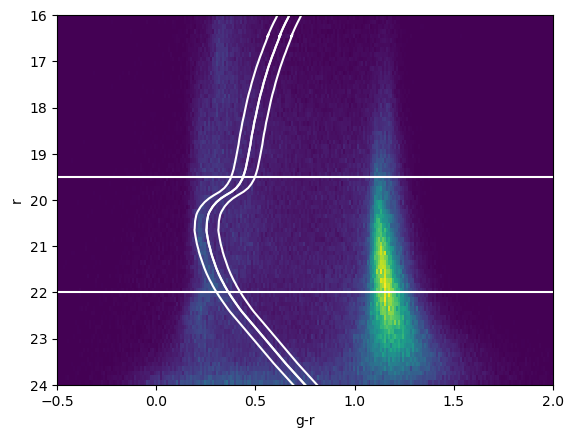

In [19]:
# load Ibata+19
hdul = fits.open('../data/pal_5_cfht_ibata17.fit')
data = hdul[1].data
hdul.close()

plt.hist2d(data['g0mag']-data['r0mag'], data['r0mag'], bins=(np.arange(-0.5,2.01,0.01), np.arange(16,24.1,0.1)))#, norm=mpl.colors.LogNorm())

# apply CMD mask
iso = iso_cfht_list[2]
mask = iso['label'] <= 3
x = iso["g'mag"][mask]-iso["r'mag"][mask]
y = iso["r'mag"][mask]+16.6
interp = interp1d(y, x, bounds_error=False, fill_value=999)

plt.plot(x+0.03, y, c='w')
plt.plot(x-0.03, y, c='w')
plt.hlines([19.5, 22], -0.5, 2.0, color='w')

color_width = 0.05

mask = (data['g0mag']-data['r0mag'] > interp(data['r0mag'])-color_width)
mask &= (data['g0mag']-data['r0mag'] < interp(data['r0mag'])+color_width)
mask &= (data['r0mag'] < r_limit)
mask &= (data['r0mag'] > 19.5)

ds_i19 = {}
ds_i19['Pal_5'] = sd.StreamDataset('Ibata+19', None, data['RAJ2000'][mask], data['DEJ2000'][mask], None, None, 
        None, data['r0mag'][mask], data['g0mag'][mask]-data['r0mag'][mask], None, None, None, None, None, gc.loc['Pal_5'])

# Now, the background
mask = (data['g0mag']-data['r0mag'] > interp(data['r0mag'])+color_width)
mask &= (data['g0mag']-data['r0mag'] < interp(data['r0mag'])+3*color_width)
mask &= (data['r0mag'] < r_limit)
mask &= (data['r0mag'] > 19.5)

plt.plot(x+0.03, y, c='w')
plt.plot(x+0.09, y, c='w')

ds_i19_bg = {}
ds_i19_bg['Pal_5'] = sd.StreamDataset('Ibata+19', None, data['RAJ2000'][mask], data['DEJ2000'][mask], None, None, 
        None, data['r0mag'][mask], data['g0mag'][mask]-data['r0mag'][mask], None, None, None, None, None, gc.loc['Pal_5'])

plt.ylim(24,16)
plt.xlabel('g-r')
plt.ylabel('r')
plt.show()

In [20]:
ds_i19['Pal_5'].construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
ds_i19['Pal_5'].construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)
ds_i19_bg['Pal_5'].construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
ds_i19_bg['Pal_5'].construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)

In [21]:
ds_i19['Pal_5'].apply_mask((ds_i19['Pal_5'].phi1<14) & (ds_i19['Pal_5'].phi1>-14))
ds_i19_bg['Pal_5'].apply_mask((ds_i19_bg['Pal_5'].phi1<14) & (ds_i19_bg['Pal_5'].phi1>-14))

In [225]:
# load Ibata+24
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

ds = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5904', 'NGC_6101', 
    'NGC_1261', 'NGC_5466', 'NGC_7099', 'NGC_7089']
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 16, 23, 26, 62, 67, 
    12, 57, 77, 76], dtype=int)

gc_stream_list = ['NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_3201', 'NGC_4590',
    'NGC_5139', 'Pal_5', 'NGC_5904', 'NGC_6101', 'NGC_6341', 'NGC_6397'] # remove 7089: too few stars; remove 1261, 5466, 7099: can't fit
gc_stream_ids = np.array([3, 16, 23, 26, 34, 47, 
    54, 61, 62, 67, 68, 69], dtype=int)
color_list = ['k', 'r', 'b', 'gray', 'g', 'm', 'c', 'pink', 'orange', 'brown', 'purple', 'tan']

# gc_stream_list = ['Pal_5'] # test case
# gc_stream_ids = np.array([61], dtype=int)

ds_i24 = {}
for i, name in tqdm(zip(gc_stream_ids, gc_stream_list)):
    d = ds[ds['stream_id'] == i]
    ds_i24[name] = sd.StreamDataset('Ibata+24', d['star_id'], d['ra'], d['dec'], d['plx'], d['mu_ra'], 
        d['mu_dec'], d['G'], d['BP-RP'], None, d['vr'], d['evr'], d['rvr'], d['stream_id'], gc.loc[name])
    ds_i24[name].cut_mag(G_limit)
    ds_i24[name].construct_greatcircle()
    ds_i24[name].construct_greatcircle_coord()
    ds_i24[name].construct_polynomial_coord(deg=4)

12it [00:37,  3.09s/it]


In [237]:
# generate mock stream

pot_agama = agama.Potential("../data/MWPotential2014.ini")

t_tot = 8000 * u.Myr
dt = 2 * u.Myr
release_type = 'uniform'
# release_type = 'peri_only'
n_steps = (t_tot/dt).value.astype(int)
nhalf = n_steps
assert nhalf % n_steps == 0

mockstreams = {}
T_dict = {}

# for key in ['Pal_5']:
for key in gc_stream_list:
    stream = ds_i24[key]
    
    gc_mass = 10**stream.prog['logm']
    c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_pot = agama.Potential(type='Plummer', mass=gc_mass, scaleRadius=4e-3)
    gc_posvel = np.r_[gc_w0.xyz.to_value('kpc'), gc_w0.v_xyz.to_value('km/s')]
    
    time_sat, orbit_sat = ags.integrate_prog( -t_tot.to('0.978*Gyr').value, n_steps, pot_agama, gc_posvel)
    peris, apos = get_peri_apo(orbit_sat[:,0], orbit_sat[:,1], orbit_sat[:,2])
    T_dict[key] = np.mean(np.r_[peris[1:] - peris[:-1], apos[1:] - apos[:-1]]) * t_tot.to('0.978*Gyr').value / n_steps
    
    if release_type == 'uniform':
        # release particles uniformly in time
        nhalf_release = np.full(n_steps, fill_value=nhalf/n_steps, dtype=int)
    elif release_type == 'peri_only':
        # release particles only at pericenters
        nhalf_per_release = nhalf // len(peris) + 1
        nhalf_release = np.zeros(n_steps, dtype=int)
        nhalf_release[peris] = nhalf_per_release
        nhalf_release[peris[0]] = nhalf - np.sum(nhalf_release[peris[1:]])
        assert nhalf_release[peris[0]] >= 0
    
    assert np.sum(nhalf_release) == nhalf
    
    time_sat, orbit_sat, xv_stream, ic_stream, time_stream = \
        ags.create_stream(ags.create_ic_chen24, np.random.default_rng(0), -t_tot.to('0.978*Gyr').value, 2*int(t_tot/dt), 
            pot_agama, gc_posvel, gc_mass, pot_sat=gc_pot, nhalf_release=nhalf_release)
    
    mockstream = coord.Galactocentric(x=xv_stream[:,0]*u.kpc, y=xv_stream[:,1]*u.kpc, z=xv_stream[:,2]*u.kpc, 
        v_x=xv_stream[:,3]*u.km/u.s, v_y=xv_stream[:,4]*u.km/u.s, v_z=xv_stream[:,5]*u.km/u.s).transform_to(coord.ICRS())
    
    mockstream = sd.StreamDataset('mock', None, 
        mockstream.ra.to_value('deg'), mockstream.dec.to_value('deg'), 
        None, 
        mockstream.pm_ra_cosdec.to_value('mas/yr'), mockstream.pm_dec.to_value('mas/yr'), 
        None, None, 
        mockstream.distance.to_value('kpc'), mockstream.radial_velocity.to_value('km/s'), 
        None, None, None, stream.prog)
    
    mockstream.construct_greatcircle_coord(GreatCircle=stream.GreatCircle)
    mockstream.construct_polynomial_coord(p=stream.p, deg=4)
    mockstream.set_release_time(time_stream)
    mockstreams[key] = mockstream

7998 orbits complete (1090 orbits/s)
7998 orbits complete (1404 orbits/s)
7998 orbits complete (1095 orbits/s)
7998 orbits complete (888.3 orbits/s)
7998 orbits complete (3122 orbits/s)
7998 orbits complete (3841 orbits/s)
7998 orbits complete (592.4 orbits/s)
7998 orbits complete (1872 orbits/s)
7998 orbits complete (2510 orbits/s)
7998 orbits complete (5713 orbits/s)
7998 orbits complete (878.4 orbits/s)
7998 orbits complete (624.9 orbits/s)


In [86]:
print('alpha = 1, mass below 0.08 Msun: %.1f%%'%(100 * power_law_broken_imf(0, 0.08, -1) / power_law_broken_imf(0, 0.8, -1)))
print('alpha = 2, mass below 0.08 Msun: %.1f%%'%(100 * power_law_broken_imf(0, 0.08, -2) / power_law_broken_imf(0, 0.8, -2)))

alpha = 1, mass below 0.08 Msun: 5.3%
alpha = 2, mass below 0.08 Msun: 17.8%


In [138]:
def round_range(x):
    if x <= 2.5:
        return 0.5 * ((x//0.5) + 1)
    if x <= 5:
        return 2.5 * ((x//2.5) + 1)
    if x <= 25:
        return 5 * ((x//5) + 1)
    return 10 * ((x//10) + 1)


NGC_288 NGC 288

NGC_1851 NGC 1851

NGC_2298 NGC 2298

NGC_2808 NGC 2808

NGC_3201 NGC 3201

NGC_4590 M68

NGC_5139 $\omega$Cen

Pal_5 Pal 5

NGC_5904 M5

NGC_6101 NGC 6101

NGC_6341 M92

NGC_6397 NGC 6397


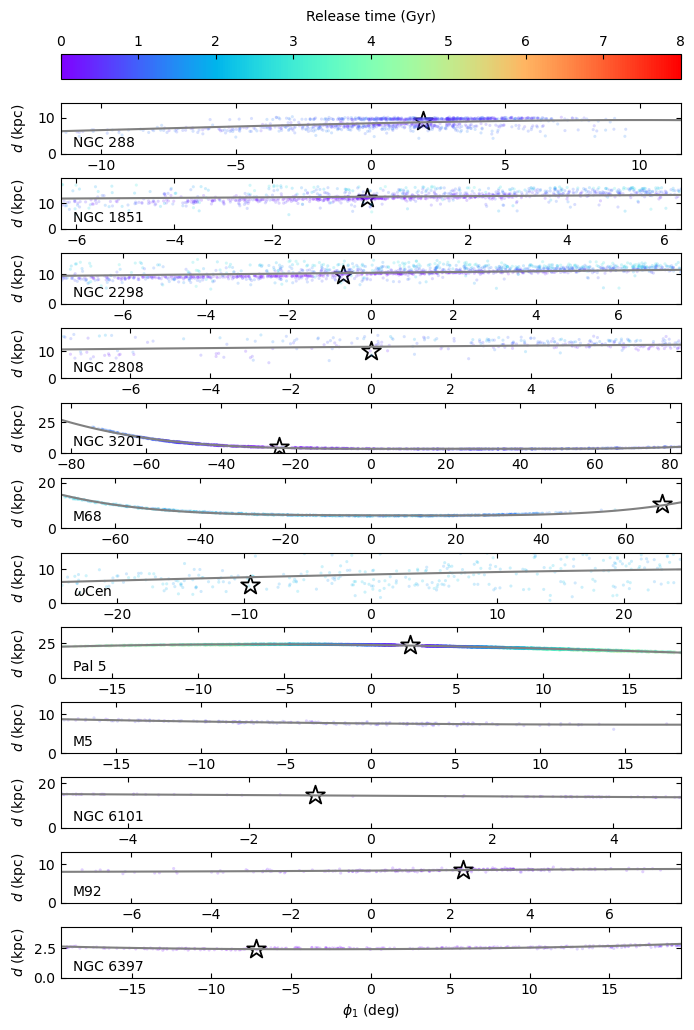

In [217]:
pd_dict = {}

fig = plt.figure(figsize=(8, 12))
gs = gridspec.GridSpec(len(gc_stream_ids)+1, 1, height_ratios=[0.5] + [1] * len(gc_stream_ids))
plt.subplots_adjust(hspace=0.5)
axs = [fig.add_subplot(gs[i+1]) for i in range(len(gc_stream_ids))]

# make color bar
cbar_ax = fig.add_subplot(gs[0])
cbar_ax.tick_params(direction='in')

cmap = colormaps['rainbow']

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=t_tot.to_value('Gyr')))
# sm.set_array([])  # Dummy array for the colorbar

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Release time (Gyr)', labelpad=10)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

# calcualte number loss rate
ndot = 2 * nhalf / t_tot.to_value('Myr')

# for key, ax0 in zip(['Pal_5'], [axs[0]]):
for key, ax0 in zip(gc_stream_list, axs):
    print('')
    print(key, display_name_convert(key))
    
    stream = ds_i24[key]
    mockstream = mockstreams[key]
    
    # plot mock stars and prog GC
    x = mockstream.phi1
    x_prog = mockstream.prog_phi1
    y = mockstream.phi2hat
    y = mockstream.d
    # ax0.scatter(x, y, s=5, ec='none', fc=cmap(-mockstream.release_time/t_tot.to_value('0.978*Gyr')), alpha=0.2, rasterized=True)
    
    # plot observed stars and prog GC
    x_prog = stream.prog_phi1
    y_prog = stream.c_prog.distance.to_value('kpc')
    ax0.scatter(x_prog, y_prog, s=200, ec='k', fc='w', marker='*', lw=1.3)
    
    width = np.percentile(stream.phi1, 90) - np.percentile(stream.phi1, 10)
    
    # plot fitted curve
    mask = (-mockstream.release_time*0.978 < t90_dict[key]) & (-mockstream.release_time*0.978 > t10_dict[key])
    if key == 'NGC_6397':
        mask &= mockstream.d < 5
    ax0.scatter(x[mask], y[mask], s=5, ec='none', fc=cmap(-mockstream.release_time[mask]/t_tot.to_value('0.978*Gyr')), alpha=0.2, rasterized=True)
    pd = np.polyfit(mockstream.phi1[mask], mockstream.d[mask], deg=4)
    pd_dict[key] = pd
    x = np.linspace(-width,width,100)
    y = np.poly1d(pd)(x)
    ax0.plot(x, y, c='gray')
    
    ax0.text(0.02, 0.08, r'%s'%display_name_convert(key), transform=ax0.transAxes, va='bottom', ha='left')
    
    ax0.set_xlim(-width,width)
    center = (np.min(y) + np.max(y)) / 2
    height = center - np.min(y)
    ax0.set_ylim(center-2*height, center+2*height)
    ax0.set_ylim(0, 1.5*np.max(y))
    ax0.set_ylabel(r'$d\ ({\rm kpc})$')

    ax0.tick_params(direction='in', bottom=True, top=True, left=True, right=True)
    
ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
fig.align_ylabels(axs)

plt.show()


NGC_288 NGC 288
t90 of segment = 1.40 Gyr
t90 of segment = 0.75 Gyr
t90 from Gaia = 1.40 Gyr
mass of a segment = 778.268 Msun
mass loss rate of segment = 3.72 Msun/Myr, age cut = 8 Gyr
mass of a segment = 717.233 Msun
mass loss rate of segment = 4.73 Msun/Myr, age cut = 8 Gyr
total mass from Gaia = 1495.5 Msun
mass loss rate from Gaia = 4.15 Msun/Myr, age cut = 8 Gyr

NGC_1851 NGC 1851
t90 of segment = 0.26 Gyr
t90 of segment = 2.90 Gyr
t90 from Gaia = 2.90 Gyr
mass of a segment = 902.267 Msun
mass loss rate of segment = 11.56 Msun/Myr, age cut = 8 Gyr
mass of a segment = 843.263 Msun
mass loss rate of segment = 10.12 Msun/Myr, age cut = 8 Gyr
total mass from Gaia = 1745.53 Msun
mass loss rate from Gaia = 10.84 Msun/Myr, age cut = 8 Gyr

NGC_2298 NGC 2298
t90 of segment = 0.23 Gyr
t90 of segment = 2.81 Gyr
t90 from Gaia = 2.81 Gyr
mass of a segment = 928.291 Msun
mass loss rate of segment = 20.16 Msun/Myr, age cut = 8 Gyr
mass of a segment = 1219.93 Msun
mass loss rate of segment = 34

/var/folders/3r/vrbpsfwj6p52jd6wsjcvn5vh0000gr/T/ipykernel_9555/3709586820.py:108: RuntimeWarning: invalid value encountered in scalar divide
  t90_right = np.sum(-select_weights*mockstream.release_time[mask]*0.978) / np.sum(select_weights)


mass of a segment = 288.721 Msun
mass loss rate of segment = 4.58 Msun/Myr, age cut = 8 Gyr
total mass from Gaia = 1357.34 Msun
mass loss rate from Gaia = 13.99 Msun/Myr, age cut = 8 Gyr

NGC_6397 NGC 6397
t90 of segment = 0.02 Gyr
t90 of segment = 2.41 Gyr
t90 from Gaia = 2.41 Gyr
mass of a segment = 38.4099 Msun
mass loss rate of segment = 9.78 Msun/Myr, age cut = 8 Gyr
mass of a segment = 1002.94 Msun
mass loss rate of segment = 11.57 Msun/Myr, age cut = 8 Gyr
total mass from Gaia = 1041.35 Msun
mass loss rate from Gaia = 11.70 Msun/Myr, age cut = 8 Gyr


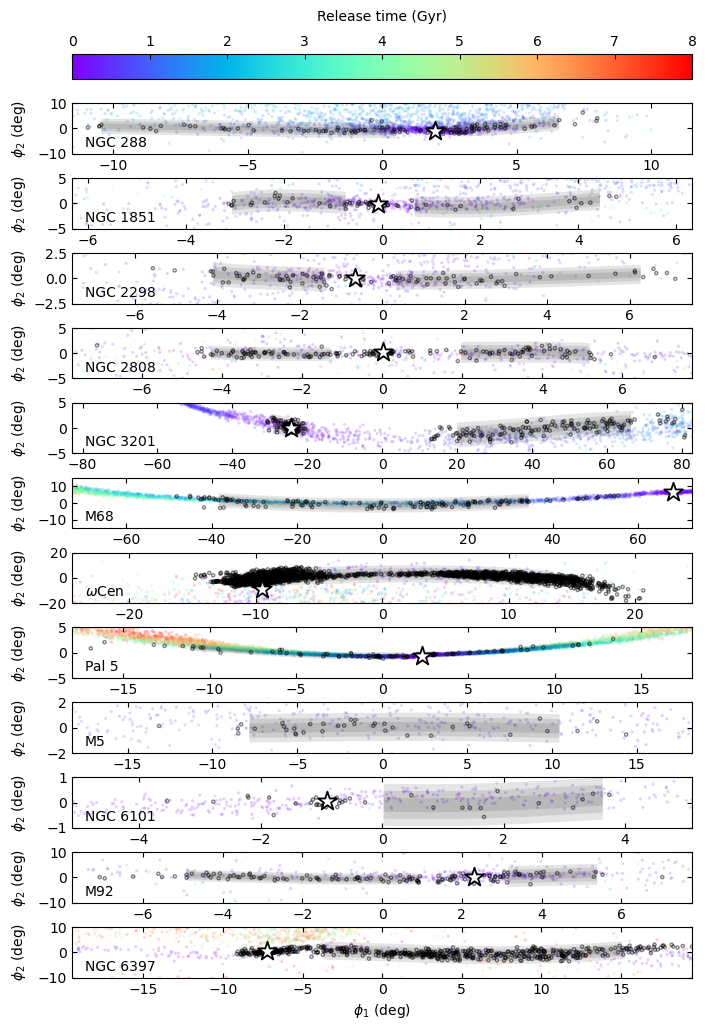

In [354]:
mdot_dict = {}
t10_dict = {}
t90_dict = {}
n_obs_dict = {}
age_cuts = [8]

# mass_func = kroupa
mass_func = lambda mmin, mmax: power_law_broken_imf(mmin, mmax, -1.5)
yaxis = 'phi2'
distance_mode = 'mock'

# fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(8,30), sharex=False, sharey=False)

fig = plt.figure(figsize=(8, 12))
gs = gridspec.GridSpec(len(gc_stream_ids)+1, 1, height_ratios=[0.5] + [1] * len(gc_stream_ids))
plt.subplots_adjust(hspace=0.5)
axs = [fig.add_subplot(gs[i+1]) for i in range(len(gc_stream_ids))]

# make color bar
cbar_ax = fig.add_subplot(gs[0])
cbar_ax.tick_params(direction='in')

cmap = colormaps['rainbow']

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=t_tot.to_value('Gyr')))
# sm.set_array([])  # Dummy array for the colorbar

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Release time (Gyr)', labelpad=10)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

# calcualte number loss rate
ndot = 2 * nhalf / t_tot.to_value('Myr')

# for key, ax0 in zip(['Pal_5'], [axs[0]]):
for key, ax0 in zip(gc_stream_list, axs):
    print('')
    print(key, display_name_convert(key))
    
    stream = ds_i24[key]
    mockstream = mockstreams[key]
    
    # plot mock stars and prog GC
    x = mockstream.phi1
    x_prog = mockstream.prog_phi1
    if yaxis == 'phi2hat':
        y = mockstream.phi2hat
    elif yaxis == 'phi2':
        y = mockstream.phi2
    else:
        raise AttributeError
    ax0.scatter(x, y, s=5, ec='none', fc=cmap(-mockstream.release_time/t_tot.to_value('0.978*Gyr')), alpha=0.2, rasterized=True)
    
    # plot observed stars and prog GC
    x = stream.phi1
    x_prog = stream.prog_phi1
    if yaxis == 'phi2hat':
        y = stream.phi2hat
        y_prog = stream.prog_phi2hat
    elif yaxis == 'phi2':
        y = stream.phi2
        y_prog = stream.prog_phi2
    else:
        raise AttributeError
    ax0.scatter(x, y, s=5, ec='k', fc='none', lw=1, alpha=0.5, rasterized=True)
    ax0.scatter(x_prog, y_prog, s=200, ec='k', fc='w', marker='*', lw=1.3)
    
    # detect segments
    segs = detect_segs(stream)
    segs_left = detect_segs(stream, percentiles=[5,15])
    segs_right = detect_segs(stream, percentiles=[85,95])
    
    # distance and distance modulus
    dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
    dist_mod = 5*(np.log10(dist)+2)
    
    # select isochrone
    iso_idx = select_iso(stream.color, stream.mag - dist_mod, iso_gaia_list, 'G_BPmag', 'G_RPmag', 'Gmag')
    
    # calculate mass of stars, minimum observable mass, maximum survived mass
    masses = calc_mass(stream.mag - dist_mod, iso_gaia_list[iso_idx], 'Gmag')
    mass_min = calc_mass(G_limit - dist_mod, iso_gaia_list[iso_idx], 'Gmag')
    mass_max = np.max(iso_gaia_list[iso_idx]['Mini'][iso_gaia_list[iso_idx]['label']<=3])
    mass_max = np.full_like(mass_min, fill_value=mass_max)
    
    # weights of stars to correct for missing stars
    weights = mass_func(0, mass_max) / mass_func(mass_min, mass_max)
    
    # print('total mass = %g Msun'%np.sum(masses*weights))
    
    mtot = 0
    t10 = np.inf
    t90 = 0
    n_obs = 0
    select_weight_sum = np.zeros_like(age_cuts)
    # now, look at individual segments
    gaus_widths = calc_selection_function(stream, segs)
    mock_gaus_widths = calc_selection_function(mockstream, segs)

    for seg, width, mockwidth, seg_left, seg_right in zip(segs, gaus_widths, mock_gaus_widths, segs_left, segs_right):
        # decide the time range
        mask = (mockstream.phi1>=seg_left[0]) & (mockstream.phi1<seg_left[1])
        select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
        t90_left = np.sum(-select_weights*mockstream.release_time[mask]*0.978) / np.sum(select_weights)
        mask = (mockstream.phi1>=seg_right[0]) & (mockstream.phi1<seg_right[1])
        select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
        t90_right = np.sum(-select_weights*mockstream.release_time[mask]*0.978) / np.sum(select_weights)
        print('t90 of segment = %.2f Gyr'%np.nanmax([t90_left, t90_right]))
        t90 = np.nanmax([t90_left, t90_right]) if np.nanmax([t90_left, t90_right]) > t90 else t90
        t10 = np.nanmin([t90_left, t90_right]) if np.nanmin([t90_left, t90_right]) < t10 else t10
    
    print('t90 from Gaia = %.2f Gyr'%t90)
    t90_dict[key] = t90
    t10_dict[key] = t10
    
    for seg, width, mockwidth, seg_left, seg_right in zip(segs, gaus_widths, mock_gaus_widths, segs_left, segs_right):
        # plot the Gaussian width
        for factor in [1,2,3]:
            if yaxis == 'phi2hat':
                x = seg
                y = np.zeros_like(seg)
            elif yaxis == 'phi2':
                x = np.linspace(seg[0], seg[1], 11)
                y = stream.fit_poly(x)
            ax0.fill_between(x, y-factor*width, y+factor*width, fc='k', ec='none', alpha=0.1)

        if distance_mode == 'prog':
            weights_seg = weights
        elif distance_mode == 'mock':
            pd = pd_dict[key]     
            dist_seg = np.poly1d(pd)(stream.phi1)
            dist_mod_seg = 5*(np.log10(dist_seg)+2)
            mass_min_seg = calc_mass(G_limit - dist_mod_seg, iso_gaia_list[iso_idx], 'Gmag')
            weights_seg = mass_func(0, mass_max) / mass_func(mass_min_seg, mass_max)
            
        mask = (stream.phi1>=seg[0]) & (stream.phi1<seg[1])
        mseg = np.sum(masses[mask]*weights_seg[mask])
        n_obs += len(stream.phi1[mask])
        
        print('mass of a segment = %g Msun'%mseg)
        mtot += mseg
    
        for i, age_cut in enumerate(age_cuts):
            mask = (mockstream.phi1>=seg[0]) & (mockstream.phi1<seg[1]) & (-mockstream.release_time*0.978<age_cut)
            select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
            mdot = ndot * mseg / np.sum(select_weights)
            select_weight_sum[i] += np.sum(select_weights)
    
            print('mass loss rate of segment = %.2f Msun/Myr, age cut = %g Gyr'%(mdot,age_cut))
    
    print('total mass from Gaia = %g Msun'%mtot)
    for i, age_cut in enumerate(age_cuts):
        print('mass loss rate from Gaia = %.2f Msun/Myr, age cut = %g Gyr'%(ndot*mtot/select_weight_sum[i],age_cut))
        mdot_dict[key] = ndot*mtot/select_weight_sum
        
    n_obs_dict[key] = n_obs

    ax0.text(0.02, 0.08, r'%s'%display_name_convert(key), transform=ax0.transAxes, va='bottom', ha='left')
    
    width = np.percentile(stream.phi1, 90) - np.percentile(stream.phi1, 10)
    height = np.percentile(stream.phi2, 90) - np.percentile(stream.phi2, 10)
    ax0.set_xlim(-width,width)
    ylim = round_range(2*height)
    ax0.set_ylim(-ylim,ylim)
    ax0.set_ylabel(r'$\phi_2\ ({\rm deg})$')

    ax0.tick_params(direction='in', bottom=True, top=True, left=True, right=True)
    
ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
fig.align_ylabels(axs)

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/stream_fit.pdf', dpi=300, bbox_inches ='tight')
plt.show()

[4.15416841]
[10.84180259]
[26.85274661]
[62.248229]
[4.83779769]
[1.02773083]
[246.03843421]
[4.3497892]
[7.28976506]
[10.85276627]
[13.99320948]
[11.70058788]


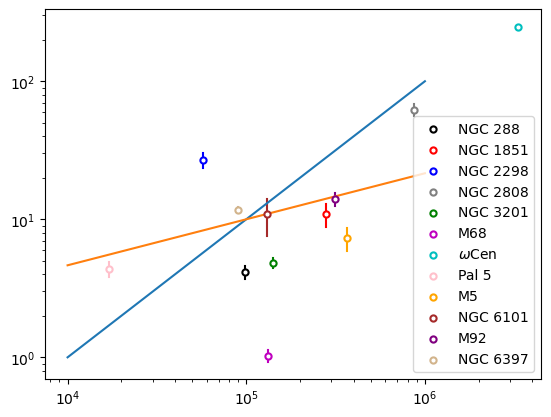

In [355]:
for key, c in zip(gc_stream_list, color_list):
    print(mdot_dict[key])
    plt.scatter(10**gc.loc[key]['logm'], mdot_dict[key], 
        ec=c, fc='w', lw=1.5, s=20, label=display_name_convert(key), zorder=100)
    plt.plot([10**gc.loc[key]['logm']]*2, [mdot_dict[key]*(1-1/np.sqrt(n_obs_dict[key])), mdot_dict[key]*(1+1/np.sqrt(n_obs_dict[key]))], 
        c=c, lw=1.5)

plt.plot([1e4, 1e6], [1e0,1e2])
plt.plot([1e4, 1e6], [10**(2/3),10**(4/3)])
plt.xscale('log')
plt.yscale('log')
plt.legend()

[4.15416841]
[10.84180259]
[26.85274661]
[62.248229]
[4.83779769]
[1.02773083]
[246.03843421]
[4.3497892]
[7.28976506]
[10.85276627]
[13.99320948]
[11.70058788]


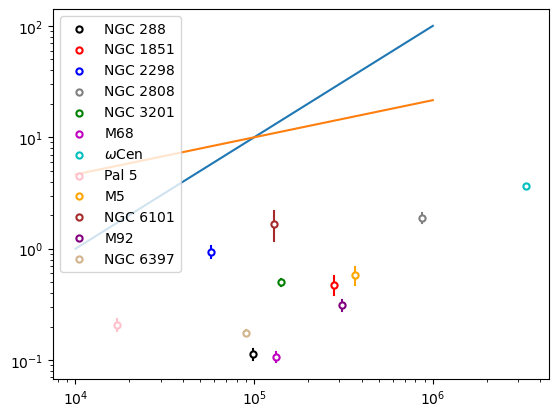

In [386]:
for key, c in zip(gc_stream_list, color_list):
    print(mdot_dict[key])
    Omega = 2*np.pi / T_dict[key]
    x = 10**gc.loc[key]['logm']
    y = mdot_dict[key]/Omega
    plt.scatter(x, y, 
        ec=c, fc='w', lw=1.5, s=20, label=display_name_convert(key), zorder=100)
    plt.plot([x]*2, [y*(1-1/np.sqrt(n_obs_dict[key])), y*(1+1/np.sqrt(n_obs_dict[key]))], 
        c=c, lw=1.5)

plt.plot([1e4, 1e6], [1e0,1e2])
plt.plot([1e4, 1e6], [10**(2/3),10**(4/3)])
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [394]:
# fit
from scipy.optimize import minimize

def neg_log_gaussian_likelihood(p, logmdot, logm, logOmega, dlogmdot):
    '''
    negative log of Gaussuan likelihood
    '''
    a = p[0]
    b = p[1]
    c = p[2]
    sig = p[3]
    sigi2 = sig**2 + dlogmdot**2
    return np.sum(np.log(sigi2) + (logmdot-a-b*logm-c*logOmega)**2/sigi2)
    
def linear_fit_maxlike_boot(logmdot, logm, logOmega, dlogmdot, size=100):
    data = np.column_stack((logmdot, logm, logOmega, dlogmdot))
    rng = np.random.default_rng(0)
    data_boot = data[rng.integers(0, len(logmdot), (size, len(logmdot)))]
    
    a_list = np.zeros(size)
    b_list = np.zeros(size)
    c_list = np.zeros(size)
    sig_list = np.zeros(size)
    
    for i, d in enumerate(data_boot):
        bnds = ((None, None), (None, None), (None, None), (0, None))
        o = minimize(neg_log_gaussian_likelihood, [0.,0.,1.,0.], 
            args=(d[:,0],d[:,1],d[:,2],d[:,3]), bounds=bnds)
        a_list[i] = o.x[0]
        b_list[i] = o.x[1]
        c_list[i] = o.x[2]
        sig_list[i] = o.x[3]
        
    return a_list, b_list, c_list, sig_list
    
logmdot = []
logm = []
logOmega = []
dlogmdot = []
for key in gc_stream_list:
    # if key == 'NGC_5139':
    #     continue
    logmdot.append(np.log10(mdot_dict[key][0]))
    logm.append(gc.loc[key]['logm'])
    logOmega.append(np.log10(2*np.pi / T_dict[key]))
    dlogmdot.append(1/np.sqrt(n_obs_dict[key])/np.log(10))
logmdot = np.array(logmdot)
logm = np.array(logm)
logOmega = np.array(logOmega)
dlogmdot = np.array(dlogmdot)

In [395]:
a, b, c, sig = linear_fit_maxlike_boot(logmdot, logm, logOmega, dlogmdot, 100)

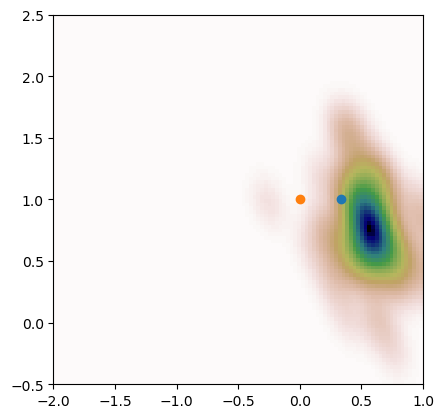

In [396]:
xmin = -2
xmax = 1
ymin = -0.5
ymax = 2.5

X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([b, c])
kernel = gaussian_kde(values)
Z = np.reshape(kernel(positions).T, X.shape)

plt.imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r, extent=[xmin, xmax, ymin, ymax])

plt.scatter(1/3,1)
plt.scatter(0,1)

In [387]:
T_dict

{'NGC_288': 0.17066962537527738,
 'NGC_1851': 0.27441647274522246,
 'NGC_2298': 0.21878589237190801,
 'NGC_2808': 0.19079267698899602,
 'NGC_3201': 0.6519960878456477,
 'NGC_4590': 0.6546634658131057,
 'NGC_5139': 0.09385551909449755,
 'Pal_5': 0.2991858625612532,
 'NGC_5904': 0.5012951601908657,
 'NGC_6101': 0.9642808452624404,
 'NGC_6341': 0.14033293868618377,
 'NGC_6397': 0.09512811259473114}

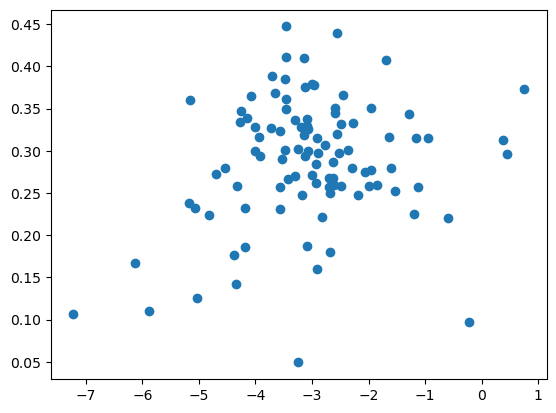

In [361]:
plt.scatter(a,sig)

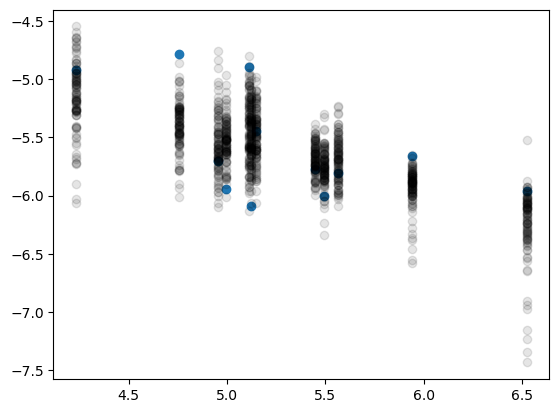

In [363]:
plt.scatter(logm, logmdot-logm-logOmega)

for i in range(len(a)):
    plt.scatter(logm, a[i]+b[i]*logm+c[i]*logOmega-logOmega, c='k', alpha=0.1, lw=1)

### Estimate the mass of Pal 5 from CFHT

**Method 1: cut a different region in CMD as background**

**Disliked by Eric**

mass of a segment = 23838.3 Msun
mass of a segment = 11299.4 Msun
total mass from CFHT = 35137.7 Msun


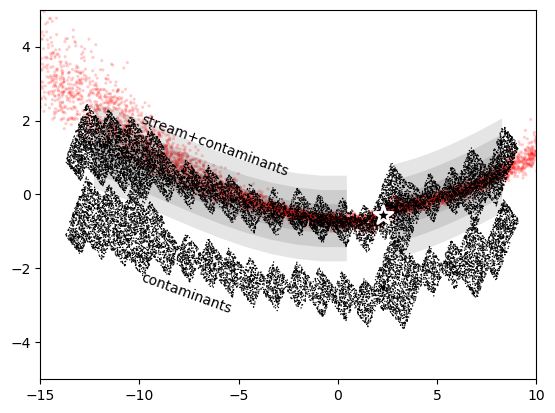

In [88]:
key = 'Pal_5'
mass_func = kroupa
yaxis = 'phi2'

stream = ds_i19[key]
stream_bg = ds_i19_bg[key]

# plot mock stars and prog GC
x = mockstream.phi1
x_prog = mockstream.prog_phi1
if yaxis == 'phi2hat':
    y = mockstream.phi2hat
elif yaxis == 'phi2':
    y = mockstream.phi2
else:
    raise AttributeError
plt.scatter(x, y, s=5, ec='none', fc='r', alpha=0.2)

# plot observed stars and prog GC
x = stream.phi1
x_bg = stream_bg.phi1
x_prog = stream.prog_phi1
if yaxis == 'phi2hat':
    y = stream.phi2hat
    y_bg = stream_bg.phi2hat
    y_prog = stream.prog_phi2hat
elif yaxis == 'phi2':
    y = stream.phi2
    y_bg = stream_bg.phi2
    y_prog = stream.prog_phi2
else:
    raise AttributeError
plt.scatter(x, y, s=1, ec='none', fc='k')
plt.scatter(x_bg, y_bg-2, s=1, ec='none', fc='k')
plt.scatter(x_prog, y_prog, s=200, ec='w', fc='k', marker='*', lw=2)

# detect segments
segs = detect_segs(stream)

# distance and distance modulus
dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
dist_bg = np.full_like(stream_bg.phi1, fill_value=stream_bg.c_prog.distance.to_value('kpc'))
dist_mod = 5*(np.log10(dist)+2)
dist_bg_mod = 5*(np.log10(dist_bg)+2)

# select isochrone
iso_idx = select_iso(stream.color, stream.mag - dist_mod, iso_cfht_list, "g'mag", "r'mag", "r'mag")

# calculate mass of stars, minimum observable mass, maximum survived mass
masses = calc_mass(stream.mag - dist_mod, iso_cfht_list[iso_idx], "r'mag")
masses_bg = calc_mass(stream_bg.mag - dist_bg_mod, iso_cfht_list[iso_idx], "r'mag")
mass_min = calc_mass(r_limit - dist_mod, iso_cfht_list[iso_idx], "r'mag")
mass_min_bg = calc_mass(r_limit - dist_bg_mod, iso_cfht_list[iso_idx], "r'mag")
mass_max = np.max(iso_cfht_list[iso_idx]['Mini'][iso_cfht_list[iso_idx]['label']<=3])

# weights of stars to correct for missing stars
weights = mass_func(0, mass_max) / mass_func(mass_min, mass_max)
weights_bg = mass_func(0, mass_max) / mass_func(mass_min_bg, mass_max)

# print('total mass = %g Msun'%(np.sum(masses*weights)-np.sum(masses_bg*weights_bg)))

mtot = 0

# now, look at individual segments
gaus_widths = calc_selection_function(stream, segs)
for seg, width in zip(segs, gaus_widths):
    # plot the Gaussian width
    for factor in [1,2,3]:
        if yaxis == 'phi2hat':
            x = seg
            y = np.zeros_like(seg)
        elif yaxis == 'phi2':
            x = np.linspace(seg[0], seg[1], 11)
            y = stream.fit_poly(x)
        plt.fill_between(x, y-factor*width, y+factor*width, fc='k', ec='none', alpha=0.1)

    mask = (stream.phi1>seg[0]) & (stream.phi1<seg[1])
    mask_bg = (stream_bg.phi1>seg[0]) & (stream_bg.phi1<seg[1])
        
    print('mass of a segment = %g Msun'%(np.sum(masses[mask]*weights[mask])-np.sum(masses_bg[mask_bg]*weights_bg[mask_bg])))
    # print('mass of a segment = %g Msun'%(np.sum(masses[mask]*weights[mask])))
    # print('mass of a segment = %g Msun'%(np.sum(masses_bg[mask_bg]*weights_bg[mask_bg])))
    mtot += np.sum(masses[mask]*weights[mask])-np.sum(masses_bg[mask_bg]*weights_bg[mask_bg])

print('total mass from CFHT = %g Msun'%mtot)

plt.xlim(-15,10)
plt.ylim(-5,5)

plt.text(-10, 0.5, 'stream+contaminants', rotation=-20)
plt.text(-10, -3.2, 'contaminants', rotation=-20)

plt.show()

**Method 2: cut the outer region as background**

**first, estimate area using Monte-Carlo method**

In [89]:
# all data
all_i19 = sd.StreamDataset('Ibata+19', None, data['RAJ2000'], data['DEJ2000'], None, None, 
        None, data['r0mag'], data['g0mag']-data['r0mag'], None, None, None, None, None, gc.loc['Pal_5'])
all_i19.construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
all_i19.construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)

In [90]:
def get_area(xsize, ysize, bg_start=0.5, above=True, all=False, left=-np.inf, right=np.inf):
    mask = (all_i19.phi1>=left) & (all_i19.phi1<=right) 
    if all:
        x = all_i19.phi1[mask]
        y = all_i19.phi2hat[mask]
        counts = binned_statistic_2d(x, y, None, 'count', bins=[np.arange(-14,10+xsize,xsize), np.arange(-1.5,1.5+ysize,ysize)])[0].astype(int)
    elif above:
        mask &= (all_i19.phi2hat>=bg_start)
        x = all_i19.phi1[mask]
        y = all_i19.phi2hat[mask]
        counts = binned_statistic_2d(x, y, None, 'count', bins=[np.arange(-14,10+xsize,xsize), np.arange(bg_start,1.5+ysize,ysize)])[0].astype(int)
    else:
        mask &= (all_i19.phi2hat<=bg_start)
        x = all_i19.phi1[mask]
        y = all_i19.phi2hat[mask]
        counts = binned_statistic_2d(x, y, None, 'count', bins=[np.arange(-14,10+xsize,xsize), -np.arange(bg_start,1.5+ysize,ysize)[::-1]])[0].astype(int)

    return np.sum(counts>0) * xsize * ysize


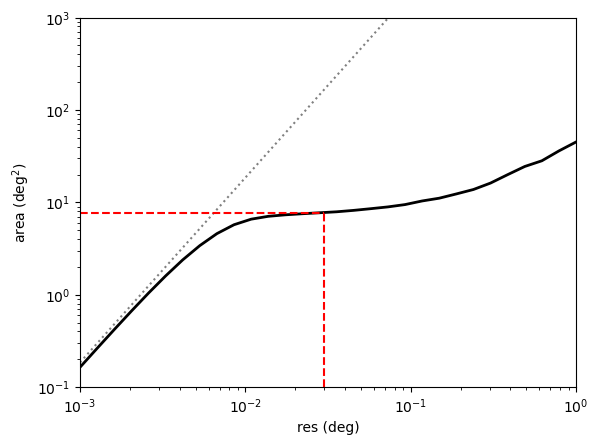

In [91]:
bg_start=0.5

res = np.logspace(-3,0,30)
areas = [get_area(r, r, bg_start) + get_area(r, r, bg_start, above=False) for r in res]

plt.plot(res, areas, c='k', lw=2)

plt.plot(res, len(all_i19.phi1[(all_i19.phi2hat>=bg_start)|(all_i19.phi2hat<=-bg_start)])*res*res, c='gray', ls=':')

annotate_r = 0.03
annotate_area = get_area(annotate_r, annotate_r, bg_start) + get_area(annotate_r, annotate_r, bg_start, above=False)
plt.hlines(annotate_area, 1e-3, annotate_r, color='r', ls='--')
plt.vlines(annotate_r, 1e-1, annotate_area, color='r', ls='--')

plt.xlabel('res (deg)')
plt.ylabel(r'area (deg$^2$)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-3, 1e0)
plt.ylim(1e-1, 1e3)

plt.show()

In [92]:
key = 'Pal_5'
bg_start = 0.5
sizex = 0.03
sizey = 0.03

area_all = get_area(sizex, sizey, all=True)
area_above = get_area(sizex, sizey, bg_start=bg_start)
mask_above = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat>=bg_start)&(ds_i19[key].phi2hat<=1.5)
print(len(ds_i19[key].phi1[mask_above])*area_all/area_above)

area_below = get_area(sizex, sizey, bg_start=bg_start, above=False)
mask_below = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat<=-bg_start)&(ds_i19[key].phi2hat>=-1.5)
print(len(ds_i19[key].phi1[mask_below])*area_all/area_below)

mask_out = mask_above | mask_below
area_out = area_above + area_below
print(len(ds_i19[key].phi1[mask_out])*area_all/area_out)


10675.089992800575
10552.239496742304
10611.640519842189


mass of a segment = 14486.9 Msun
mass loss rate of segment = 5.47295 Msun/Myr
mass of a segment = 6941.82 Msun
mass loss rate of segment = 6.36281 Msun/Myr
total mass from CFHT = 21428.7 Msun
mass loss rate from CFHT = 5.73267 Msun/Myr


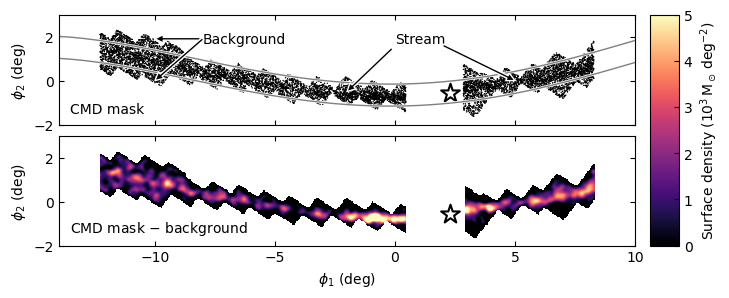

In [99]:
fig = plt.figure(figsize=(8, 3))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.05], height_ratios=[1, 1], wspace=0.05, hspace=0.1)

########## scatter plot ##########

ax0 = fig.add_subplot(gs[0, 0])

key = 'Pal_5'
mass_func = kroupa
bg_start = 0.5
sizex = 0.03
sizey = 0.03
yaxis = 'phi2'

stream = ds_i19[key]
mockstream = mockstreams[key]

# calcualte number loss rate
ndot = 2 * nhalf / t_tot.to_value('Myr')

# detect segments
segs = detect_segs(stream)

# # plot mock stars and prog GC
# x = mockstream.phi1
# x_prog = mockstream.prog_phi1
# if yaxis == 'phi2hat':
#     y = mockstream.phi2hat
# elif yaxis == 'phi2':
#     y = mockstream.phi2
# else:
#     raise AttributeError
# plt.scatter(x, y, s=5, ec='none', fc='r', alpha=0.2)

# plot observed stars and prog GC
x = stream.phi1
x_bg = stream_bg.phi1
x_prog = stream.prog_phi1
if yaxis == 'phi2hat':
    y = stream.phi2hat
    y_bg = stream_bg.phi2hat
    y_prog = stream.prog_phi2hat
elif yaxis == 'phi2':
    y = stream.phi2
    y_bg = stream_bg.phi2
    y_prog = stream.prog_phi2
else:
    raise AttributeError
    
for seg in segs:
    mask = (stream.phi1>seg[0]) & (stream.phi1<seg[1])
    ax0.scatter(x[mask], y[mask], s=1, ec='none', fc='k', rasterized=True)
    
ax0.scatter(x_prog, y_prog, s=200, ec='k', fc='w', marker='*', lw=1.5)

# plot background boundaries
if yaxis == 'phi2hat':
    ax0.hlines([bg_start, -bg_start], -14, 10, color='gray', ls='--')
elif yaxis == 'phi2':
    x = np.linspace(-14, 10, 49)
    y = stream.fit_poly(x)
    ax0.plot(x, y+bg_start, c='w', lw=2)
    ax0.plot(x, y+bg_start, c='gray', lw=1)
    ax0.plot(x, y-bg_start, c='w', lw=2)
    ax0.plot(x, y-bg_start, c='gray', lw=1)

# distance and distance modulus
dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
dist_mod = 5*(np.log10(dist)+2)

# select isochrone
iso_idx = select_iso(stream.color, stream.mag - dist_mod, iso_cfht_list, "g'mag", "r'mag", "r'mag")

# calculate mass of stars, minimum observable mass, maximum survived mass
masses = calc_mass(stream.mag - dist_mod, iso_cfht_list[iso_idx], "r'mag")
mass_min = calc_mass(r_limit - dist_mod, iso_cfht_list[iso_idx], "r'mag")
mass_max = np.max(iso_cfht_list[iso_idx]['Mini'][iso_cfht_list[iso_idx]['label']<=3])

mask_above = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat>=bg_start)&(ds_i19[key].phi2hat<=1.5)
mask_below = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat<=-bg_start)&(ds_i19[key].phi2hat>=-1.5)
mask_bg = mask_above | mask_below

# weights of stars to correct for missing stars
weights = mass_func(0, mass_max) / mass_func(mass_min, mass_max)

# background density
density_bg = np.sum(masses[mask_bg]*weights[mask_bg]) / area_out

# print('total mass = %g Msun'%(np.sum(masses*weights)-np.sum(masses_bg*weights_bg)))

mtot = 0
select_weight_sum = 0

# now, look at individual segments
gaus_widths = calc_selection_function(stream, segs)
for seg, width in zip(segs, gaus_widths):

    mask = (stream.phi1>seg[0]) & (stream.phi1<seg[1])

    area_seg = get_area(sizex, sizey, all=True, left=seg[0], right=seg[1])

    mseg = np.sum(masses[mask]*weights[mask])-density_bg*area_seg
    print('mass of a segment = %g Msun'%mseg)
    
    mtot += mseg
    
    mask = (mockstream.phi1>=seg[0]) & (mockstream.phi1<seg[1])
    select_weights = np.ones_like(mockstream.phi2hat[mask]) # uniform selection function
    # select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
    mdot = ndot * mseg / np.sum(select_weights)
    select_weight_sum += np.sum(select_weights)

    print('mass loss rate of segment = %g Msun/Myr'%mdot)

print('total mass from CFHT = %g Msun'%mtot)
print('mass loss rate from CFHT = %g Msun/Myr'%(ndot*mtot/select_weight_sum))

# ax0.text(-8, 0.5, 'background', rotation=-20)
ax0.annotate('Background', xy=(-10, 1.9), xytext=(-8, 1.9), va='center', ha='left',
    arrowprops=dict(fc='k', ec='w', width=2, headwidth=6, headlength=6, lw=1))
ax0.annotate('', xy=(-10, 0), xytext=(-8, 1.9), va='center', ha='left',
    arrowprops=dict(fc='k', ec='w', width=2, headwidth=6, headlength=6, lw=1))
ax0.annotate('Stream', xy=(-2, -0.5), xytext=(0, 1.9), va='center', ha='left',
    arrowprops=dict(fc='k', ec='w', width=2, headwidth=6, headlength=6, lw=1))
ax0.annotate('', xy=(5, 0), xytext=(2, 1.6), va='center', ha='left',
    arrowprops=dict(fc='k', ec='w', width=2, headwidth=6, headlength=6, lw=1))

ax0.text(0.02, 0.08, r'CMD mask', transform=ax0.transAxes, va='bottom', ha='left')

ax0.set_ylabel(r'$\phi_2\ ({\rm deg})$')
ax0.set_xlim(-14,10)
ax0.set_ylim(-2,3)
ax0.set_xticklabels([])

ax0.tick_params(direction='in', bottom=True, top=True, left=True, right=True)

########## kde plot ##########

ax0 = fig.add_subplot(gs[1, 0])

xsize = 0.05
ysize = 0.05

ax0.scatter(x_prog, y_prog, s=200, ec='k', fc='w', marker='*', lw=1.5)

xbins = np.arange(-14,10+xsize,xsize)
ybins = np.arange(-2,3+ysize,ysize)
xcenter = (xbins[1:] + xbins[:-1]) / 2
ycenter = (ybins[1:] + ybins[:-1]) / 2

counts = binned_statistic_2d(all_i19.phi1, all_i19.phi2, None, 'count', bins=[xbins, ybins])[0].astype(int)

x = stream.phi1
y = stream.phi2
data = np.row_stack([x,y])
kde = gaussian_kde(data, weights=masses*weights, bw_method=0.1)
kde.covariance = np.eye(data.shape[0]) * kde.factor**2
kde.cho_cov = linalg.cholesky(np.eye(data.shape[0]), lower=True)* kde.factor

# density = binned_statistic_2d(x, y, masses*weights, 'sum', bins=[xbins, ybins])[0] / xsize / ysize

xx, yy = np.meshgrid(xcenter, ycenter, indexing='ij')
points = np.row_stack([xx.flatten(), yy.flatten()])
Z = np.reshape(kde(points), xx.shape)

Zhere = Z * np.sum(masses*weights)
Zhere -= density_bg
Zhere[counts==0] = np.nan

mask = np.ones_like(Zhere, dtype=bool)
for seg in segs:
    mask[(xx>=seg[0]) & (xx<=seg[1])] = False
    
Zhere[mask] = np.nan

cax0 = ax0.imshow(np.rot90(Zhere)/1e3, extent=[xbins.min(), xbins.max(), ybins.min(), ybins.max()], vmin=0, vmax=5, cmap='magma')

ax0.text(0.02, 0.08, r'CMD mask $-$ background', transform=ax0.transAxes, va='bottom', ha='left')

ax0.set_aspect('auto')

ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
ax0.set_ylabel(r'$\phi_2\ ({\rm deg})$')

ax0.set_xlim(-14,10)
ax0.set_ylim(-2,3)

ax0.tick_params(direction='in', bottom=True, top=True, left=True, right=True)

cbar_ax = fig.add_subplot(gs[:, 1])  # This spans both rows
fig.colorbar(cax0, cax=cbar_ax, label=r'Surface density $\rm (10^3\,M_\odot\,deg^{-2})$')
cbar_ax.tick_params(direction='in')

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/cfht_background_substract.pdf', dpi=300, bbox_inches ='tight')
plt.show()